# **Pre-processing**

In [ ]:
# Use this cell to connect to your Google Drive
# allow all permissions
# should output "Mounted at /content/drive"
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pwd
!ls /content/drive

# this should output:
# /content
# MyDrive  Shareddrives

/content
MyDrive  Shareddrives


In [ ]:
!ls /content/drive/MyDrive/ufo.csv
# should output "/content/drive/MyDrive/ufo.csv"

/content/drive/MyDrive/ufo.csv


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/drive/MyDrive/ufo.csv')
df.head()

/tmp/ipython-input-4204754941.py:4: DtypeWarning: Columns (5,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/MyDrive/ufo.csv')


,datetime,city,state,country,shape,duration (seconds),duration (hours/min),comments,date posted,latitude,longitude
0,10/10/1949 20:30,san marcos,tx,us,cylinder,2700,45 minutes,This event took place in early fall around 194...,4/27/2004,29.8830556,-97.941111
1,10/10/1949 21:00,lackland afb,tx,NaN,light,7200,1-2 hrs,1949 Lackland AFB&#44 TX. Lights racing acros...,12/16/2005,29.38421,-98.581082
2,10/10/1955 17:00,chester (uk/england),NaN,gb,circle,20,20 seconds,Green/Orange circular disc over Chester&#44 En...,1/21/2008,53.2,-2.916667
3,10/10/1956 21:00,edna,tx,us,circle,20,1/2 hour,My older brother and twin sister were leaving ...,1/17/2004,28.9783333,-96.645833
4,10/10/1960 20:00,kaneohe,hi,us,light,900,15 minutes,AS a Marine 1st Lt. flying an FJ4B fighter/att...,1/22/2004,21.4180556,-157.803611


In [ ]:
#convert latitude to numeric values
df = df[df.latitude.str.contains(r'^[0-9.]+$', na=False)]
df['latitude'] = df['latitude'].astype(float)

In [ ]:
#filtering out incorrect datetimes
indices_to_drop = df[df['datetime'].str.contains(r'( 24:)')].index
df.drop(indices_to_drop, inplace=True)
df['datetime'] = pd.to_datetime(df['datetime'])

df.head()

/tmp/ipython-input-3928278118.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  indices_to_drop = df[df['datetime'].str.contains(r'( 24:)')].index


,datetime,city,state,country,shape,duration (seconds),duration (hours/min),comments,date posted,latitude,longitude
0,1949-10-10 20:30:00,san marcos,tx,us,cylinder,2700,45 minutes,This event took place in early fall around 194...,4/27/2004,29.883056,-97.941111
1,1949-10-10 21:00:00,lackland afb,tx,NaN,light,7200,1-2 hrs,1949 Lackland AFB&#44 TX. Lights racing acros...,12/16/2005,29.384210,-98.581082
2,1955-10-10 17:00:00,chester (uk/england),NaN,gb,circle,20,20 seconds,Green/Orange circular disc over Chester&#44 En...,1/21/2008,53.200000,-2.916667
3,1956-10-10 21:00:00,edna,tx,us,circle,20,1/2 hour,My older brother and twin sister were leaving ...,1/17/2004,28.978333,-96.645833
4,1960-10-10 20:00:00,kaneohe,hi,us,light,900,15 minutes,AS a Marine 1st Lt. flying an FJ4B fighter/att...,1/22/2004,21.418056,-157.803611


In [ ]:
#dropping unnecessary/duplicate features
df = df.drop('duration (hours/min)', axis=1)
df = df.drop('date posted', axis=1)
df.head()

,datetime,city,state,country,shape,duration (seconds),comments,latitude,longitude
0,1949-10-10 20:30:00,san marcos,tx,us,cylinder,2700,This event took place in early fall around 194...,29.883056,-97.941111
1,1949-10-10 21:00:00,lackland afb,tx,NaN,light,7200,1949 Lackland AFB&#44 TX. Lights racing acros...,29.384210,-98.581082
2,1955-10-10 17:00:00,chester (uk/england),NaN,gb,circle,20,Green/Orange circular disc over Chester&#44 En...,53.200000,-2.916667
3,1956-10-10 21:00:00,edna,tx,us,circle,20,My older brother and twin sister were leaving ...,28.978333,-96.645833
4,1960-10-10 20:00:00,kaneohe,hi,us,light,900,AS a Marine 1st Lt. flying an FJ4B fighter/att...,21.418056,-157.803611


In [ ]:
#data is exclusively USA now
df = df[df['country'] == 'us']

#making data exclusively continental US, so dropping alaska, hawaii, and puerto rico
df = df[(df['state'] != 'ak') & (df['state'] != 'hi') & (df['state'] != 'pr')]

In [ ]:
#uniform columns
df.columns = df.columns.str.strip().str.lower()

In [ ]:
#calculate range of longitude coordinates
max_longitude = -66.949778
min_longitude = -124.771694
longitude_range = max_longitude - min_longitude

#calculating range of latitude coordinates
max_latitude = 49.384467
min_latitude = 24.446667
latitude_range = max_latitude - min_latitude

#put instances into a tuple grid
df['lat_bin'] = pd.cut(df['latitude'], bins=10, labels=False)
df['long_bin'] = pd.cut(df['longitude'], bins=10, labels=False)
df['grid'] = list(zip(df['lat_bin'], df['long_bin']))

df.head()

,datetime,city,state,country,shape,duration (seconds),comments,latitude,longitude,lat_bin,long_bin,grid
0,1949-10-10 20:30:00,san marcos,tx,us,cylinder,2700,This event took place in early fall around 194...,29.883056,-97.941111,2,4,"(2, 4)"
3,1956-10-10 21:00:00,edna,tx,us,circle,20,My older brother and twin sister were leaving ...,28.978333,-96.645833,1,4,"(1, 4)"
5,1961-10-10 19:00:00,bristol,tn,us,sphere,300,My father is now 89 my brother 52 the girl wit...,36.595000,-82.188889,4,7,"(4, 7)"
7,1965-10-10 23:45:00,norwalk,ct,us,disk,1200,A bright orange color changing to reddish colo...,41.117500,-73.408333,6,8,"(6, 8)"
8,1966-10-10 20:00:00,pell city,al,us,disk,180,Strobe Lighted disk shape object observed clos...,33.586111,-86.286111,3,6,"(3, 6)"


In [ ]:
#converting tuples to ordinal numbers
tuples = sorted(df['grid'].unique())

tuple_to_index = {t: i for i, t in enumerate(tuples)}
df['grid_id'] = df['grid'].map(tuple_to_index)

#drop old grid columns
df = df.drop('lat_bin', axis=1)
df = df.drop('long_bin', axis=1)
df = df.drop('grid', axis=1)

In [ ]:
#sorts by latitude basically so check that texas, the southernmost, is in the first few rows and maine is in the last few
df.sort_values(by='grid_id')

,datetime,city,state,country,shape,duration (seconds),comments,latitude,longitude,grid_id
15504,2014-01-16 18:15:00,mcallen,tx,us,teardrop,300,My mother and I were traveling South on Biccen...,26.203056,-98.229722,0
9639,2012-11-15 05:15:00,brownsville,tx,us,oval,120,Oval shape light&#44gliding within some clouds...,25.901389,-97.497222,0
44545,2013-05-26 23:25:00,sullivan city,tx,us,triangle,300,Triangle object flying over my house in South ...,26.277222,-98.563333,0
7705,2005-11-10 01:05:00,port isabel,tx,us,disk,360,Large disc shaped object with red lights on so...,26.073056,-97.208333,0
5198,2013-10-28 20:20:00,brownsville,tx,us,circle,90,2 orange fiery&#44 round objects flew over bro...,25.901389,-97.497222,0
...,...,...,...,...,...,...,...,...,...,...
52056,1999-06-27 23:42:00,ashland,me,us,triangle,120,I was standing outside when I saw a light in t...,46.631111,-68.406667,77
23580,2008-01-28 00:00:00,presque isle,me,us,fireball,120,Huge fireball emitting a white light that lit ...,46.681111,-68.016389,77
40829,2004-04-08 06:00:00,maine (location unspecified),me,us,unknown,180,A dream where I traveled out of my body into s...,46.820000,-67.923611,77
33073,2012-03-22 01:00:00,presque isle,me,us,triangle,120,Two amber colored objects appeared to be playi...,46.681111,-68.016389,77


In [ ]:
import re

#clean comment text
df['comments'] = (df['comments'].astype(str).str.lower().str
                 .replace(r'[^a-z\s]', '', regex=True).str.strip())

#list of possible colors
colors = ['red', 'orange', 'yellow', 'green', 'blue', 'purple', 'pink',
          'white', 'grey', 'gray', 'black', 'silver', 'gold', 'brown', 'amber',
          'bright']

#making encoded columns for each color
for color in colors:
  df[color] = df['comments'].str.contains(color).astype(int)


#list of possible sizes
sizes = ["small", "medium", "large", "huge", "tiny", "massive"]

#making encoded columns for each size
for size in sizes:
  df[size] = df['comments'].str.contains(size).astype(int)


#list of possible behaviors
behaviors = ["hovering", "moving", "zigzag", "fast", "slow", "stationary"]

#making encoded columns for each behavior
for behavior in behaviors:
  df[behavior] = df['comments'].str.contains(behavior).astype(int)


#list of possible directions
directions = ["north", "south", "east", "west", "up", "down"]

#making encoded columns for each directions
for direction in directions:
  df[direction] = df['comments'].str.contains(direction).astype(int)


#list of possible weather
weather = ["cloudy", "clear", "rain", "storm", "fog"]

#making encoded columns for each weather
for weather_type in weather:
  df[weather_type] = df['comments'].str.contains(weather_type).astype(int)

In [ ]:
df.drop(columns=df.columns[(df == 0).all()], inplace=True)

df['duration (seconds)'] = pd.to_numeric(df['duration (seconds)'], errors='coerce')
df = df.dropna(subset=['duration (seconds)'])
df['duration (seconds)'] = df['duration (seconds)'].astype(float)
df.head()

,datetime,city,state,country,shape,duration (seconds),comments,latitude,longitude,grid_id,...,south,east,west,up,down,cloudy,clear,rain,storm,fog
0,1949-10-10 20:30:00,san marcos,tx,us,cylinder,2700.0,this event took place in early fall around it...,29.883056,-97.941111,9,...,0,0,0,0,0,0,0,0,0,0
3,1956-10-10 21:00:00,edna,tx,us,circle,20.0,my older brother and twin sister were leaving ...,28.978333,-96.645833,3,...,0,0,0,0,0,0,0,0,0,0
5,1961-10-10 19:00:00,bristol,tn,us,sphere,300.0,my father is now my brother the girl with us...,36.595000,-82.188889,29,...,0,0,0,0,0,0,0,0,0,0
7,1965-10-10 23:45:00,norwalk,ct,us,disk,1200.0,a bright orange color changing to reddish colo...,41.117500,-73.408333,48,...,0,0,0,0,0,0,0,0,0,0
8,1966-10-10 20:00:00,pell city,al,us,disk,180.0,strobe lighted disk shape object observed clos...,33.586111,-86.286111,19,...,0,0,0,0,0,0,0,0,0,0


# **Clustering**

In [ ]:
import collections
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import normalize
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

import matplotlib.cm as cm
import matplotlib.colors as mcolors

import matplotlib
import matplotlib.pyplot as plt

In [ ]:
#making a copy of the dataframe and seeing which features still have NaN values
df_copy = df.copy()
null_counts = df_copy.isna().sum()
null_counts

,0
datetime,0
city,0
state,0
country,0
shape,1252
duration (seconds),0
comments,0
latitude,0
longitude,0
grid_id,0


In [ ]:
#drop rows with missing shape values
df_cleaned = df_copy.dropna()

In [ ]:
X = df_cleaned[['latitude', 'longitude', 'red', 'orange', 'yellow', 'green', 'blue',
        'purple', 'pink', 'white', 'grey', 'gray', 'black', 'silver', 'gold',
        'brown', 'amber', 'bright', 'small', 'medium', 'large', 'huge', 'tiny',
        'duration (seconds)', 'shape', 'datetime']].copy()

#turning datetime into other features, scikit doesn't like them
X['year'] = X['datetime'].dt.year
X['month'] = X['datetime'].dt.month
X['day'] = X['datetime'].dt.day
X['hour'] = X['datetime'].dt.hour

#dropping OG datetime column
X = X.drop(columns=['datetime'])

In [ ]:
X_dummied = pd.get_dummies(X)
X_dummied.head()

,latitude,longitude,red,orange,yellow,green,blue,purple,pink,white,...,shape_light,shape_other,shape_oval,shape_pyramid,shape_rectangle,shape_round,shape_sphere,shape_teardrop,shape_triangle,shape_unknown
0,29.883056,-97.941111,1,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
3,28.978333,-96.645833,0,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
5,36.595000,-82.188889,0,0,0,0,0,0,0,0,...,False,False,False,False,False,False,True,False,False,False
7,41.117500,-73.408333,1,1,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
8,33.586111,-86.286111,0,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
X_numeric = X_dummied.apply(pd.to_numeric)

In [ ]:
normalized_array = normalize(X_numeric, norm='l2')
X_normalized = pd.DataFrame(normalized_array, columns=X_dummied.columns)
X_normalized.head()

,latitude,longitude,red,orange,yellow,green,blue,purple,pink,white,...,shape_light,shape_other,shape_oval,shape_pyramid,shape_rectangle,shape_round,shape_sphere,shape_teardrop,shape_triangle,shape_unknown
0,0.008970,-0.029397,0.000300,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
1,0.014793,-0.049338,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
2,0.018427,-0.041384,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000504,0.0,0.0,0.0
3,0.017845,-0.031859,0.000434,0.000434,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
4,0.016992,-0.043655,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0


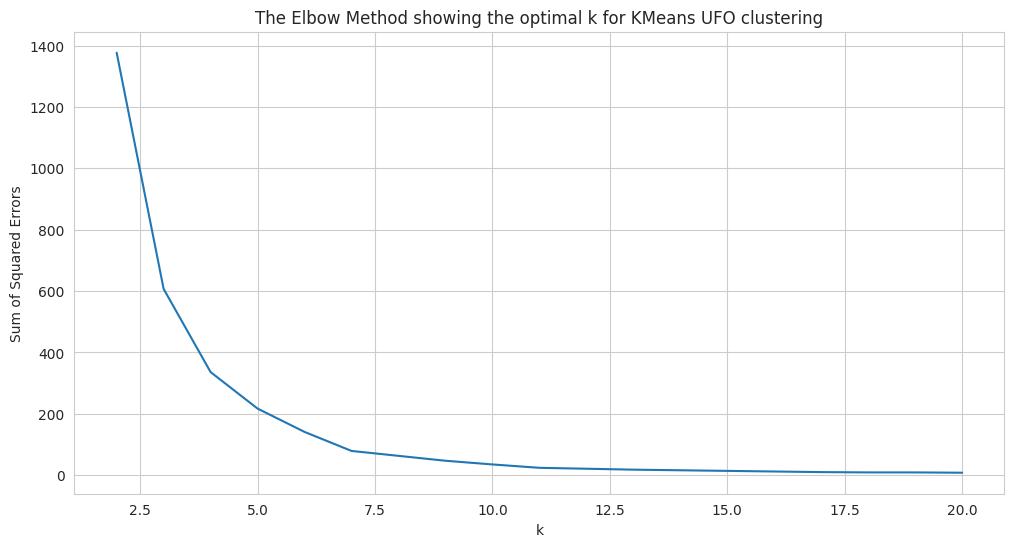

In [ ]:
sses = {}

for k in np.arange(2, 21):
  kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
  kmeans.fit(X_normalized)

  sse = kmeans.inertia_
  sses[int(k)] = int(sse)

plt.figure(figsize=(12, 6))

plt.plot(sses.keys(), sses.values())
plt.xlabel('k')
plt.ylabel('Sum of Squared Errors')
plt.title('The Elbow Method showing the optimal k for KMeans UFO clustering')
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import MiniBatchKMeans

sample = X_normalized.sample(n=4000, random_state=42)

kVals = range(2,18)
inertias = []
sillhouetteScores = []

for k in kVals:
  model = MiniBatchKMeans(n_clusters=k,batch_size=2048,max_iter=100,random_state=42)
  labels = model.fit_predict(X_normalized)
  score = silhouette_score(sample, model.predict(sample))
  inertias.append(model.inertia_)
  sillhouetteScores.append(score)

optimalK = kVals[sillhouetteScores.index(max(sillhouetteScores))]
print("Optimal K:", optimalK)


Optimal K: 2


In [ ]:
kmeans = MiniBatchKMeans(n_clusters=optimalK, batch_size= 2048, max_iter = 300, random_state=42)
df_cleaned['cluster'] = kmeans.fit_predict(X_normalized)

/tmp/ipython-input-1944866082.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['cluster'] = kmeans.fit_predict(X_normalized)


/tmp/ipython-input-3490352818.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Paired', optimalK)


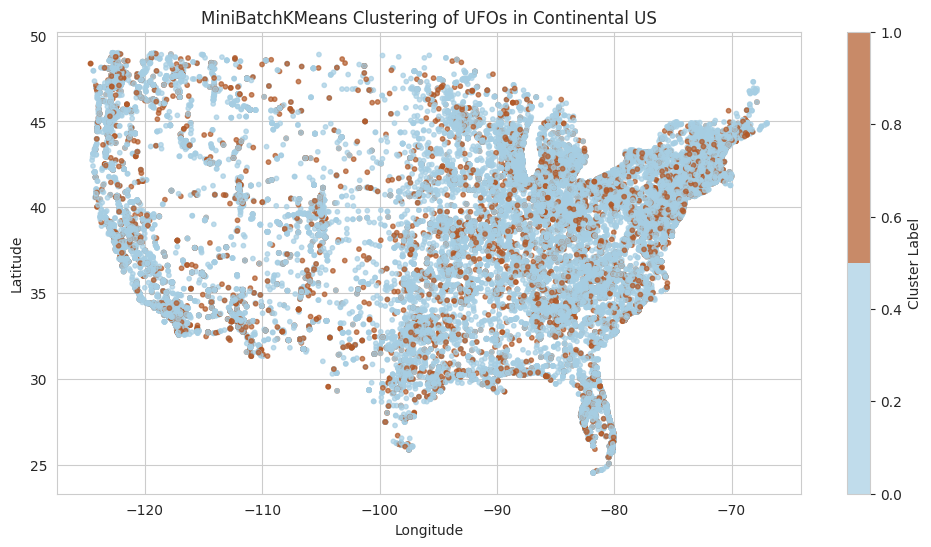

In [ ]:
plt.figure(figsize=(12, 6))

cmap = cm.get_cmap('Paired', optimalK)

scatter = plt.scatter(df_cleaned['longitude'], df_cleaned['latitude'],
                      c=df_cleaned['cluster'], cmap=cmap,s=10,alpha=0.7)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('MiniBatchKMeans Clustering of UFOs in Continental US')

cbar = plt.colorbar(scatter)
cbar.set_label('Cluster Label')

plt.show()

In [ ]:
#clustering based solely on latitude and longitude to see if there is a regional clustering pattern
x_geo_sample = X.sample(n=4000, random_state=42)[['latitude', 'longitude']]
regional_cluster = DBSCAN(eps=1.5, min_samples=10).fit(x_geo_sample)
x_geo_sample['regional_cluster'] = regional_cluster.labels_

/tmp/ipython-input-561573884.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Paired', num_clusters)


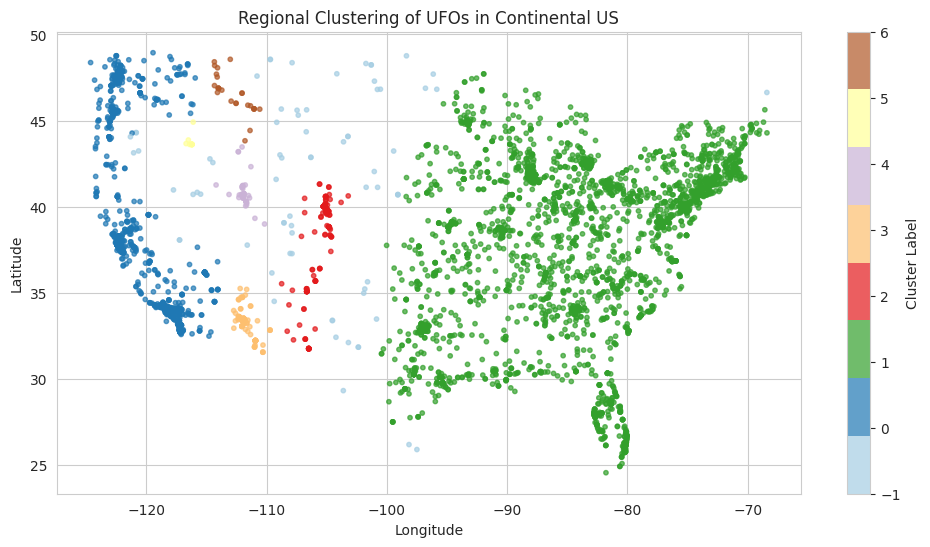

In [ ]:
plt.figure(figsize=(12, 6))

num_clusters = len(np.unique(x_geo_sample['regional_cluster']))

cmap = cm.get_cmap('Paired', num_clusters)

scatter = plt.scatter(x_geo_sample['longitude'], x_geo_sample['latitude'],
                      c=x_geo_sample['regional_cluster'], cmap=cmap,s=10,alpha=0.7)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Regional Clustering of UFOs in Continental US')

cbar = plt.colorbar(scatter)
cbar.set_label('Cluster Label')

plt.show()

In [ ]:
print(regional_cluster.labels_)

[0 0 1 ... 1 1 1]


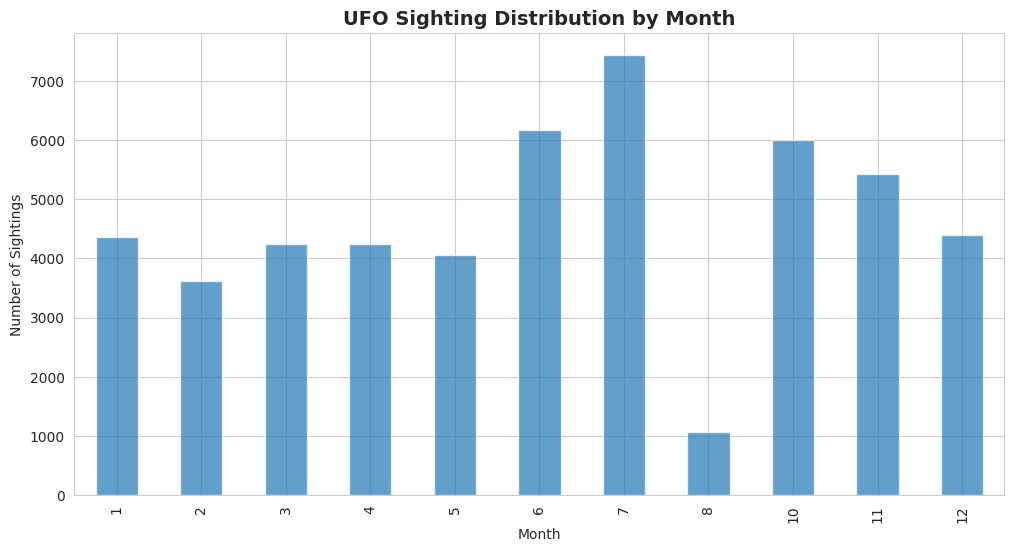

In [ ]:
df_temp = df_cleaned.copy()
df_temp['month'] = df_temp['datetime'].dt.month
df_temp['hour'] = df_temp['datetime'].dt.hour
df_temp['year'] = df_temp['datetime'].dt.year
df_temp['day'] = df_temp['datetime'].dt.day
plt.figure(figsize=(12, 6))
graph_by_month = df_temp.groupby(['month']).size()
graph_by_month.plot(kind='bar', colormap='tab10', alpha=0.7)
plt.title('UFO Sighting Distribution by Month', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Sightings')
plt.show()








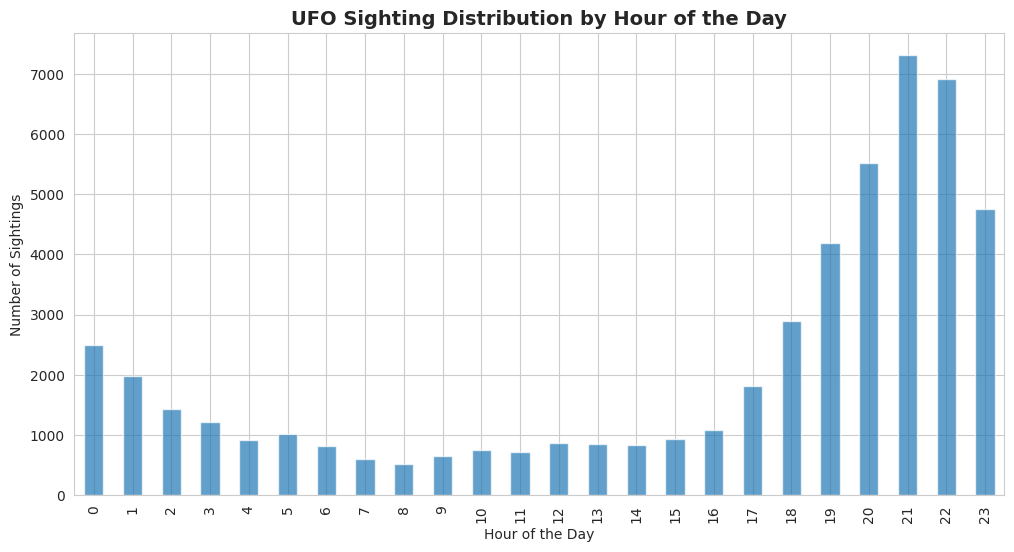

In [ ]:
plt.figure(figsize=(12, 6))
graph_by_month = df_temp.groupby(['hour']).size()
graph_by_month.plot(kind='bar', colormap='tab10', alpha=0.7)
plt.title('UFO Sighting Distribution by Hour of the Day', fontsize=14, fontweight='bold')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Sightings')
plt.show()